<a href="https://colab.research.google.com/github/amalendukithu06-cyber/DSA/blob/main/Intermediate_Assessment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [2]:
train = pd.read_csv("train_LZdllcl.csv")
test = pd.read_csv("test_2umaH9m.csv")
sample = pd.read_csv("sample_submission_M0L0uXE.csv")

In [3]:
print("Train Shape :", train.shape)
print("Test Shape :", test.shape)
print("Sample Shape :", sample.shape)

Train Shape : (54808, 14)
Test Shape : (23490, 13)
Sample Shape : (23490, 2)


In [4]:
train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [6]:
train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,1.000000,99.000000,1.000000


In [7]:
train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [8]:
train.duplicated().sum()

np.int64(0)

In [9]:
train["is_promoted"].value_counts()

,count
is_promoted,
0,50140
1,4668


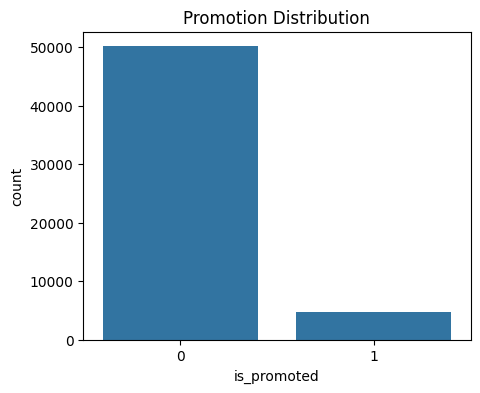

In [10]:
plt.figure(figsize=(5,4))

sns.countplot(data=train, x="is_promoted")

plt.title("Promotion Distribution")

plt.show()

In [11]:
print(train.isnull().sum())
print()
print(test.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [12]:
train["education"].fillna(train["education"].mode()[0], inplace=True)
test["education"].fillna(test["education"].mode()[0], inplace=True)

train["previous_year_rating"].fillna(train["previous_year_rating"].median(), inplace=True)
test["previous_year_rating"].fillna(test["previous_year_rating"].median(), inplace=True)

/tmp/ipykernel_784/2132291125.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["education"].fillna(train["education"].mode()[0], inplace=True)
/tmp/ipykernel_784/2132291125.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [13]:
print(train.isnull().sum())
print()
print(test.isnull().sum())

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

employee_id             0
department              0
region                  0
education               0
gender                  0
recruitment_channel     0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
dtype: int64


In [14]:
train = train.drop("employee_id", axis=1)
test_ids = test["employee_id"]
test = test.drop("employee_id", axis=1)

In [15]:
categorical_columns = [
    "department",
    "region",
    "education",
    "gender",
    "recruitment_channel"
]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    train[column] = label_encoder.fit_transform(train[column])
    test[column] = label_encoder.transform(test[column])

In [16]:
X = train.drop("is_promoted", axis=1)

y = train["is_promoted"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print(X_train.shape)
print(X_valid.shape)

print(y_train.shape)
print(y_valid.shape)

(43846, 12)
(10962, 12)
(43846,)
(10962,)


In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [20]:
y_pred = model.predict(X_valid)

In [21]:
from sklearn.metrics import f1_score

score = f1_score(y_valid, y_pred)

print("F1 Score :", score)

F1 Score : 0.4207171314741036


In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96     10028
           1       0.82      0.28      0.42       934

    accuracy                           0.93     10962
   macro avg       0.88      0.64      0.69     10962
weighted avg       0.93      0.93      0.92     10962



In [23]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [24]:
from catboost import CatBoostClassifier

In [25]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid)
)

0:	learn: 0.2142185	test: 0.2309125	best: 0.2309125 (0)	total: 58.3ms	remaining: 29.1s
100:	learn: 0.4504132	test: 0.4355777	best: 0.4372402 (98)	total: 2.52s	remaining: 9.94s
200:	learn: 0.5028844	test: 0.4896000	best: 0.4912000 (187)	total: 4.56s	remaining: 6.79s
300:	learn: 0.5131345	test: 0.4992076	best: 0.5003959 (289)	total: 5.85s	remaining: 3.87s
400:	learn: 0.5187807	test: 0.5039370	best: 0.5039370 (397)	total: 7.1s	remaining: 1.75s
499:	learn: 0.5269531	test: 0.5125000	best: 0.5125000 (493)	total: 8.35s	remaining: 0us

bestTest = 0.5125
bestIteration = 493

Shrink model to first 494 iterations.


CatBoostClassifier(depth=6, eval_metric='F1', iterations=500, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [26]:
cat_pred = cat_model.predict(X_valid)

In [27]:
from sklearn.metrics import f1_score

score = f1_score(y_valid, cat_pred)

print("CatBoost F1 Score :", score)

CatBoost F1 Score : 0.5125


In [28]:
test_prediction = cat_model.predict(test)

In [29]:
submission = pd.DataFrame({
    "employee_id": test_ids,
    "is_promoted": test_prediction.astype(int)
})

submission.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [56]:
submission.to_csv("submission.csv", index=False)

print("submission.csv Created Successfully")

submission.csv Created Successfully


In [57]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

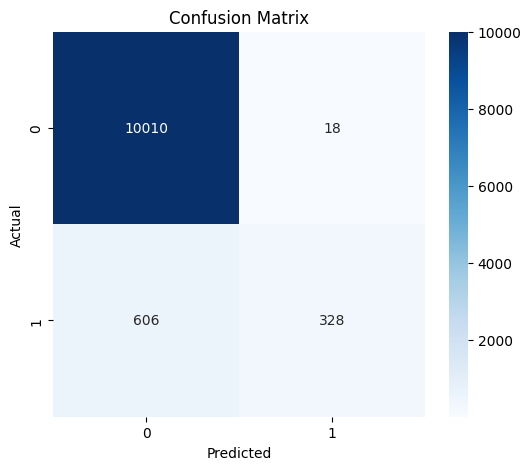

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, cat_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, cat_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     10028
           1       0.95      0.35      0.51       934

    accuracy                           0.94     10962
   macro avg       0.95      0.67      0.74     10962
weighted avg       0.94      0.94      0.93     10962



In [34]:
importance = cat_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
11,avg_training_score,36.769177
9,KPIs_met >80%,25.253028
0,department,20.819685
7,previous_year_rating,5.513909
1,region,3.285661
6,age,2.455709
8,length_of_service,2.336896
10,awards_won?,0.979717
5,no_of_trainings,0.790136
4,recruitment_channel,0.720214


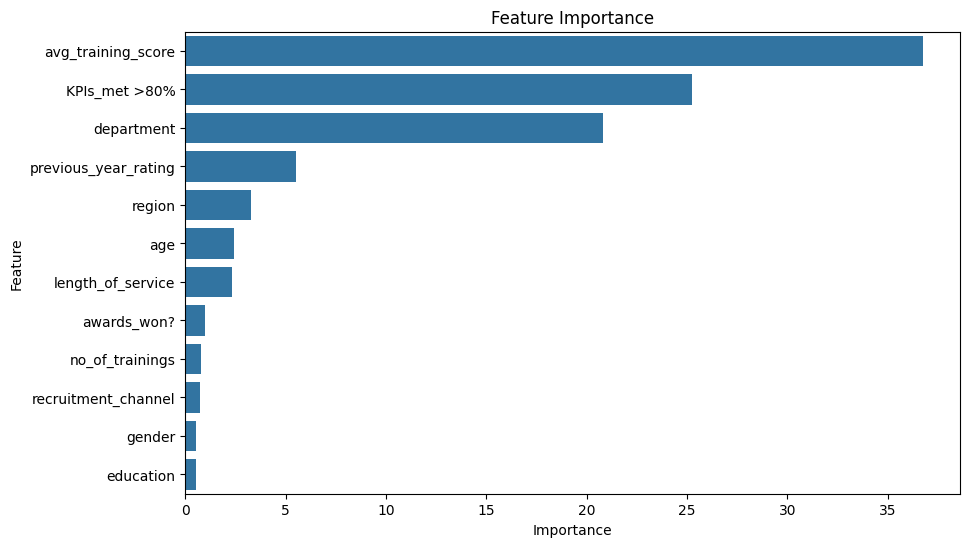

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [36]:
model_scores = pd.DataFrame({
    "Model": [
        "Random Forest",
        "CatBoost"
    ],
    "F1 Score": [
        f1_score(y_valid, y_pred),
        f1_score(y_valid, cat_pred)
    ]
})

model_scores

,Model,F1 Score
0,Random Forest,0.420717
1,CatBoost,0.512500


In [37]:
best_model = model_scores.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,F1 Score
1,CatBoost,0.512500
0,Random Forest,0.420717


In [38]:
from sklearn.model_selection import GridSearchCV

params = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [200, 500]
}

grid = GridSearchCV(
    CatBoostClassifier(verbose=0),
    params,
    scoring='f1',
    cv=3
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'depth': 4, 'iterations': 500, 'learning_rate': 0.1}
0.49932384496333326


In [39]:
best_model = grid.best_estimator_

In [40]:
prediction = best_model.predict(test)

In [41]:
submission = pd.DataFrame({
    "employee_id": test_ids,
    "is_promoted": prediction.astype(int)
})

submission.to_csv("submission.csv", index=False)

In [42]:
submission.to_csv("submission.csv", index=False)

print("submission.csv Created Successfully")

submission.csv Created Successfully


In [43]:
from google.colab import files

files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

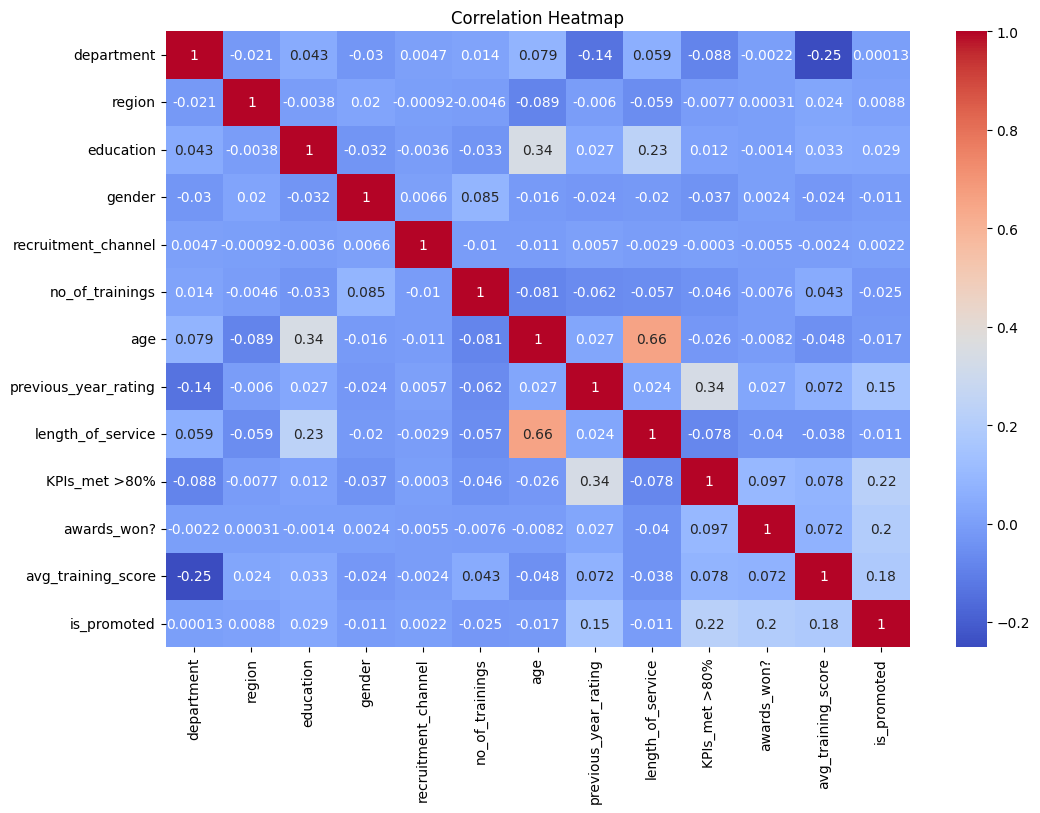

In [45]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

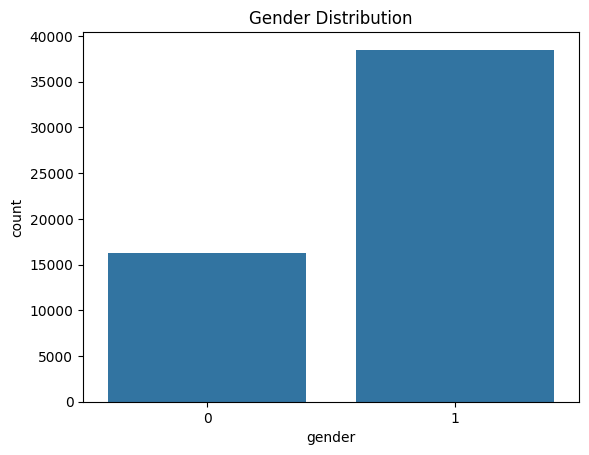

In [47]:
sns.countplot(x="gender", data=train)
plt.title("Gender Distribution")
plt.show()

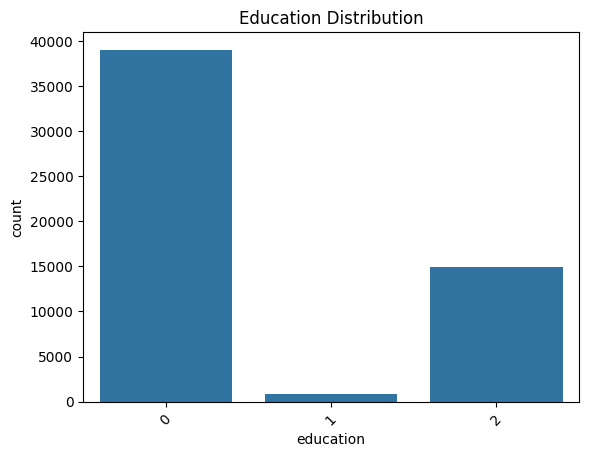

In [48]:
sns.countplot(x="education", data=train)
plt.xticks(rotation=45)
plt.title("Education Distribution")
plt.show()

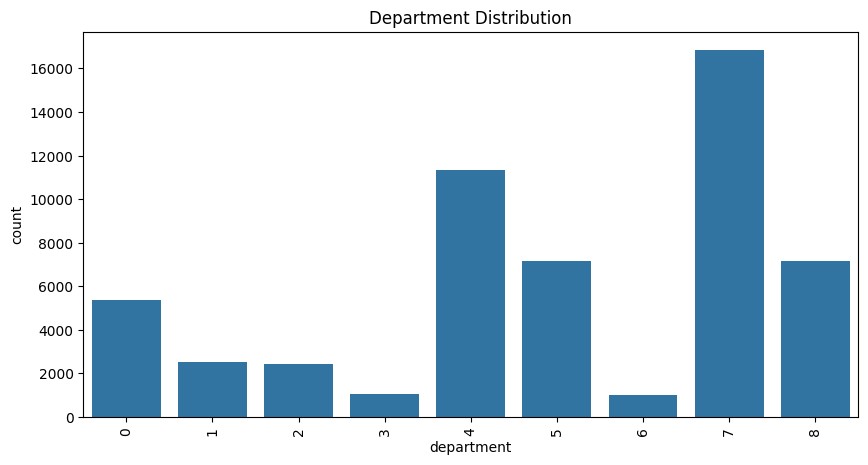

In [49]:
plt.figure(figsize=(10,5))
sns.countplot(x="department", data=train)
plt.xticks(rotation=90)
plt.title("Department Distribution")
plt.show()

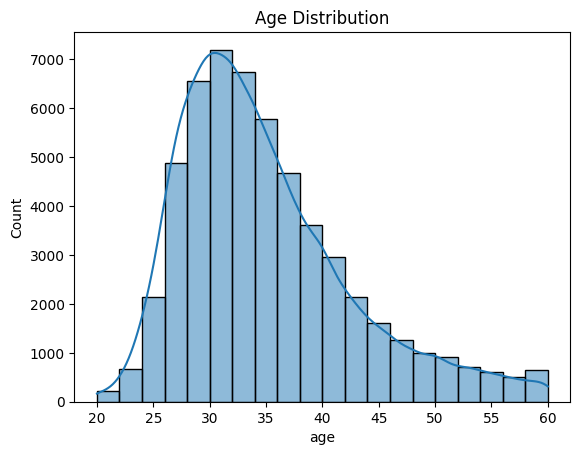

In [50]:
sns.histplot(train["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

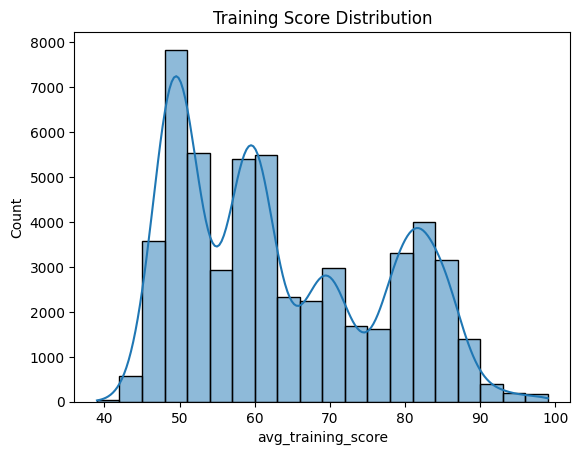

In [51]:
sns.histplot(train["avg_training_score"], bins=20, kde=True)
plt.title("Training Score Distribution")
plt.show()

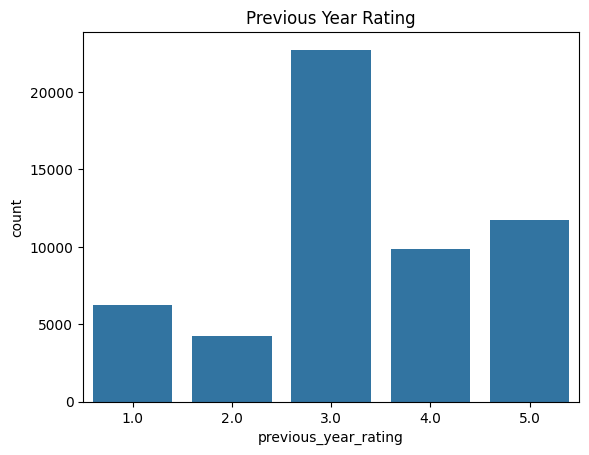

In [52]:
sns.countplot(x="previous_year_rating", data=train)
plt.title("Previous Year Rating")
plt.show()

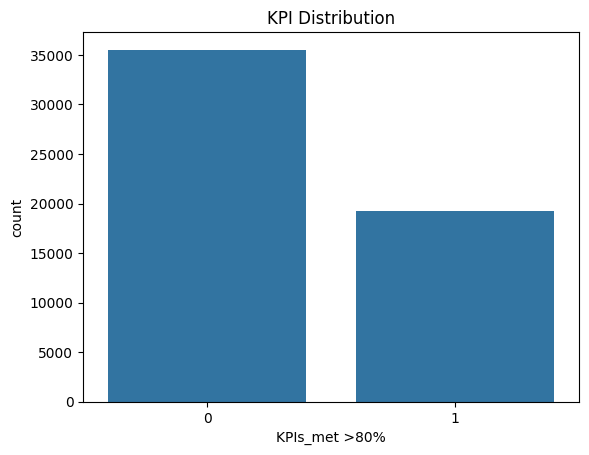

In [53]:
sns.countplot(x="KPIs_met >80%", data=train)
plt.title("KPI Distribution")
plt.show()

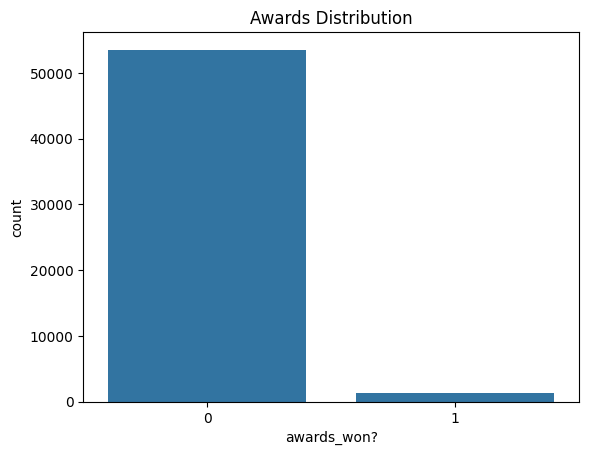

In [54]:
sns.countplot(x="awards_won?", data=train)
plt.title("Awards Distribution")
plt.show()

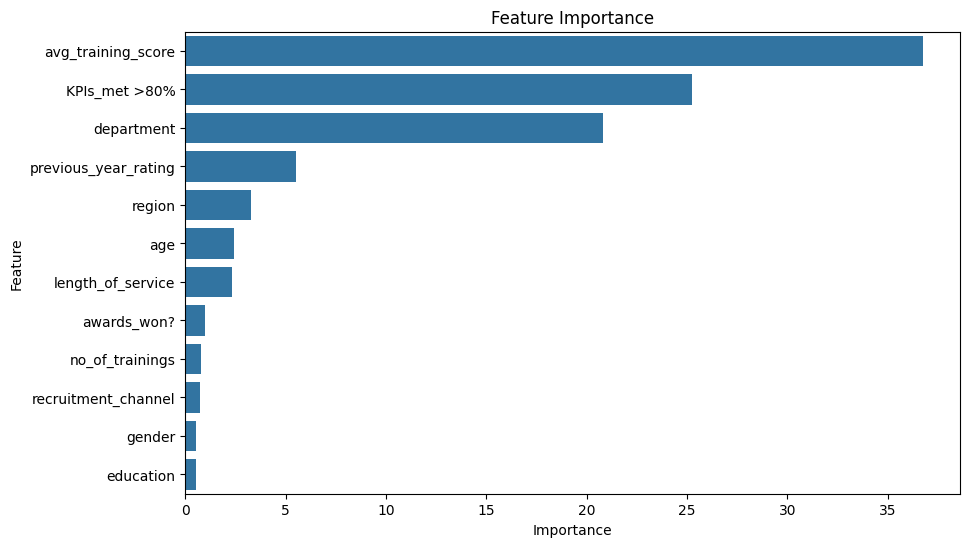

In [55]:
importance = cat_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()